In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
torch.set_default_device('cuda')

In [153]:
def stochastic_update(update_grid):
  mask = (torch.rand(64,64) > 0.5).to(torch.float32)

  channels = [update_grid[:,:,i] * mask for i in range(16)]
  return torch.stack(channels, dim=2) # Peak BT

In [154]:
def perception(grid):
  grid2 = grid.permute(2, 0, 1).unsqueeze(0)

  sobel_x = torch.tensor([[-1, 0, +1], [-2, 0, +2], [-1, 0, +1]]).unsqueeze(0).unsqueeze(0).to(torch.float32)
  sobel_x = sobel_x.repeat(16, 1, 1, 1)
  sobel_y = torch.tensor([[+1, +2, +1], [0, 0, 0], [-1, -2, -1]]).unsqueeze(0).unsqueeze(0).to(torch.float32)
  sobel_y = sobel_y.repeat(16, 1, 1, 1)

  x_conv = F.conv2d(grid2, sobel_x, stride=1, padding=1, groups=16).squeeze(0).permute(1,2,0)
  y_conv = F.conv2d(grid2, sobel_y, stride=1, padding=1, groups=16).squeeze(0).permute(1,2,0)

  return torch.cat((x_conv, y_conv, grid), dim=2)

In [155]:
def alive_mask(grid):
  mask = (F.max_pool2d(grid[:,:,3].unsqueeze(0).unsqueeze(0), stride=1, kernel_size=3, padding=1) > 0.1).to(torch.float32).squeeze(0).squeeze(0)
  channels = [grid[:,:,i] * mask for i in range(16)]
  return torch.stack(channels, dim=2)

In [156]:
class UpdateRule(nn.Module):
  def __init__(self):
    super().__init__()

    self.fc1 = nn.Linear(48, 128)
    self.fc2 = nn.Linear(128, 16)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = self.fc2(x)

    return x

In [160]:
model = UpdateRule()
model.fc2.weight.data.zero_()
model.fc2.bias.data.zero_()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')

In [161]:
optimizer = Adam(model.parameters(), lr=0.001)

sample_grid = torch.zeros((64,64,16))
for i in range(20,40):
  for j in range(20,40):
    sample_grid[i,j,:] = torch.ones(16)

epochs = 100
with torch.autograd.set_detect_anomaly(True):
  for epoch in range(epochs):
    print(f"Step {epoch}: ")
    optimizer.zero_grad()
    state_grid = torch.zeros((64,64,16))
    state_grid[32,32,:] = torch.ones(16)

    update_steps = torch.randint(64, 96, (1,))
    for step in range(update_steps):
      perception_vectors = perception(state_grid)
      update = model(perception_vectors)
      update = stochastic_update(update)

      state_grid = state_grid + update
      state_grid = alive_mask(state_grid)
    loss = 0
    for i in range(64):
      for j in range(64):
        for k in range(4):
          loss = loss + (state_grid[i,j,k] - sample_grid[i,j,k])**2 / (3*64*64)

    loss.backward()
    optimizer.step()

Step 0: 
Step 1: 
Step 2: 
Step 3: 
Step 4: 
Step 5: 
Step 6: 
Step 7: 
Step 8: 
Step 9: 
Step 10: 
Step 11: 
Step 12: 
Step 13: 
Step 14: 
Step 15: 
Step 16: 
Step 17: 
Step 18: 
Step 19: 
Step 20: 
Step 21: 
Step 22: 
Step 23: 
Step 24: 
Step 25: 
Step 26: 
Step 27: 
Step 28: 
Step 29: 
Step 30: 
Step 31: 
Step 32: 
Step 33: 
Step 34: 
Step 35: 
Step 36: 
Step 37: 
Step 38: 
Step 39: 
Step 40: 
Step 41: 
Step 42: 
Step 43: 
Step 44: 
Step 45: 
Step 46: 
Step 47: 
Step 48: 
Step 49: 
Step 50: 
Step 51: 
Step 52: 
Step 53: 
Step 54: 
Step 55: 
Step 56: 
Step 57: 
Step 58: 
Step 59: 
Step 60: 
Step 61: 
Step 62: 
Step 63: 
Step 64: 
Step 65: 
Step 66: 
Step 67: 
Step 68: 
Step 69: 
Step 70: 
Step 71: 
Step 72: 
Step 73: 
Step 74: 
Step 75: 
Step 76: 
Step 77: 
Step 78: 
Step 79: 
Step 80: 
Step 81: 
Step 82: 
Step 83: 
Step 84: 
Step 85: 
Step 86: 
Step 87: 
Step 88: 
Step 89: 
Step 90: 
Step 91: 
Step 92: 
Step 93: 
Step 94: 
Step 95: 
Step 96: 
Step 97: 
Step 98: 
Step 99: 


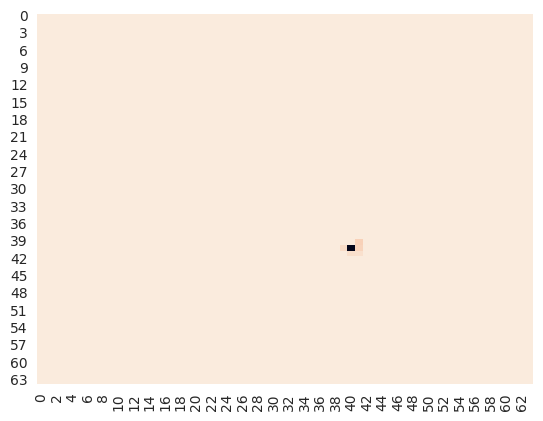

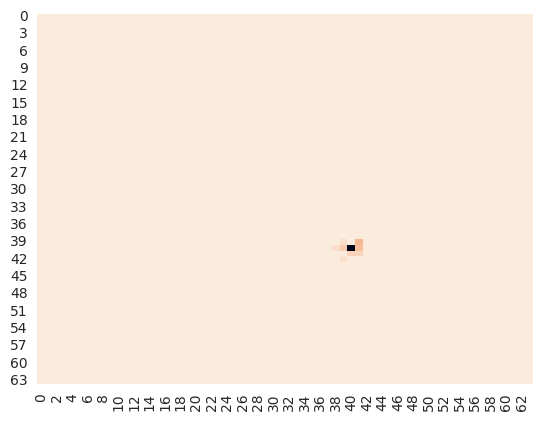

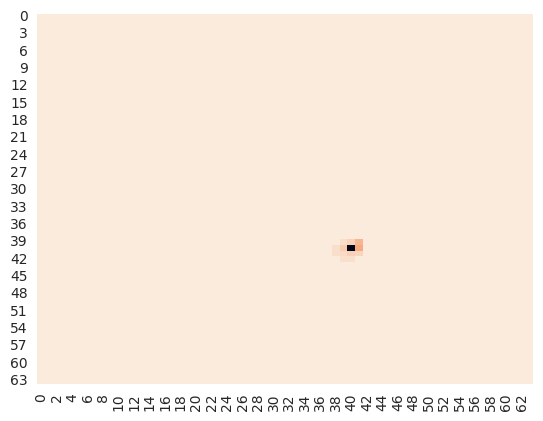

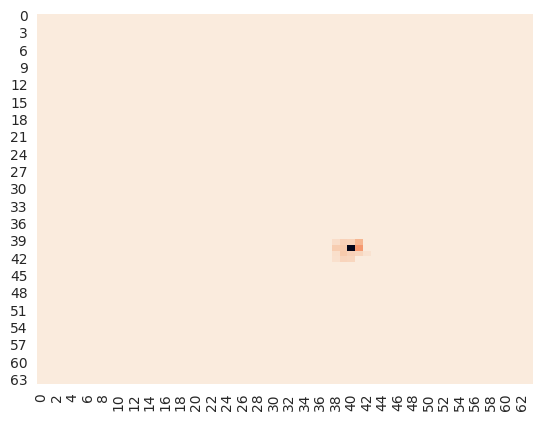

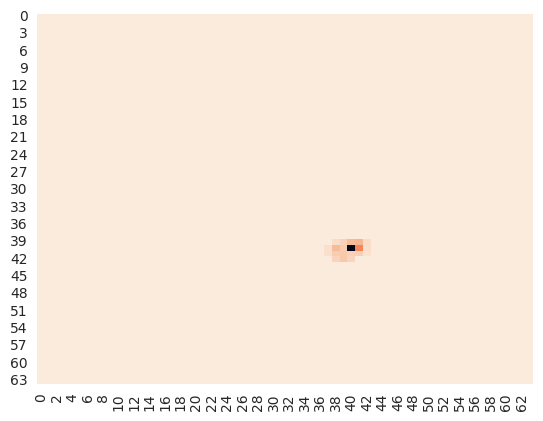

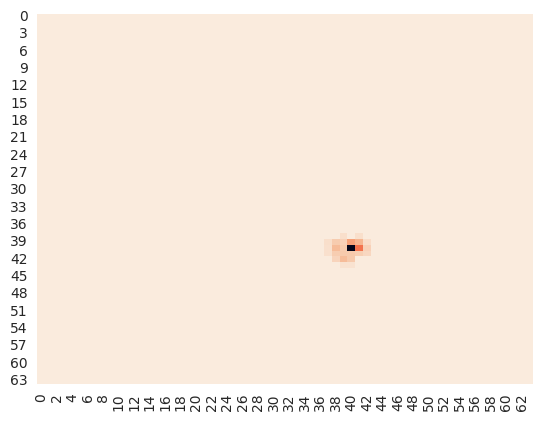

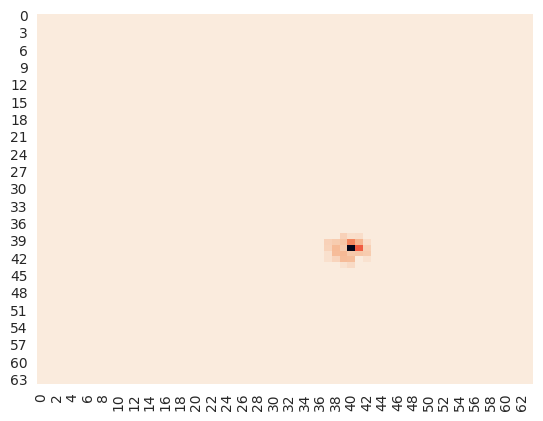

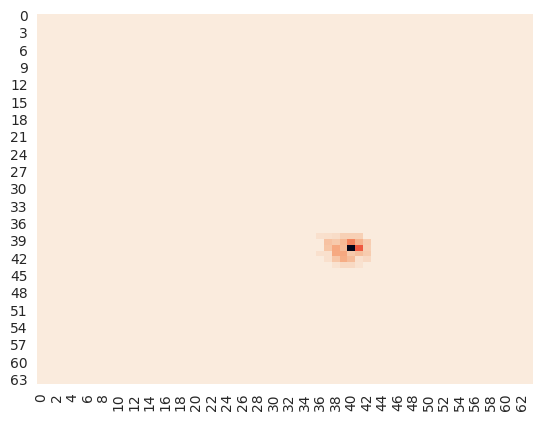

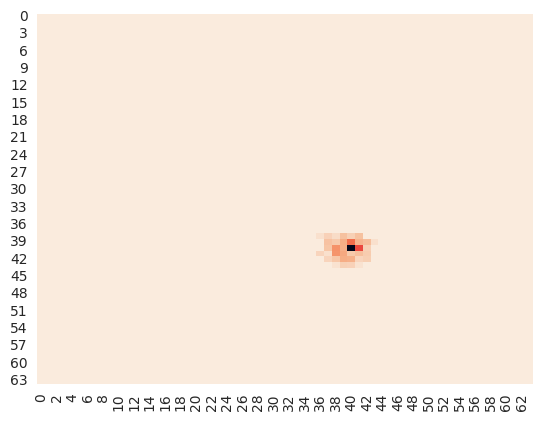

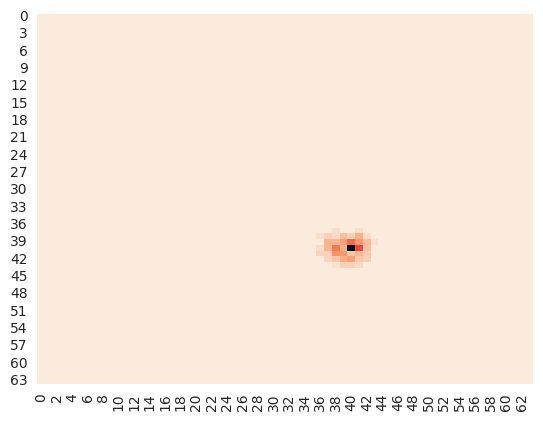

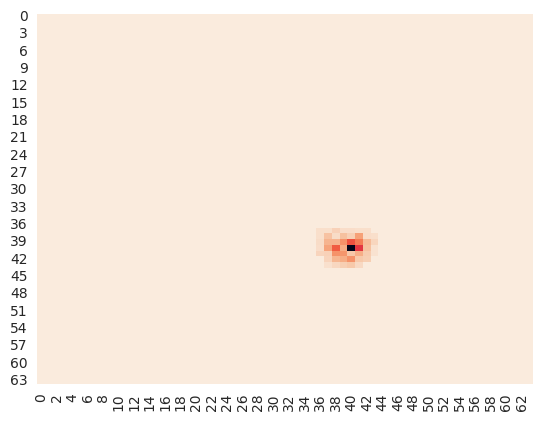

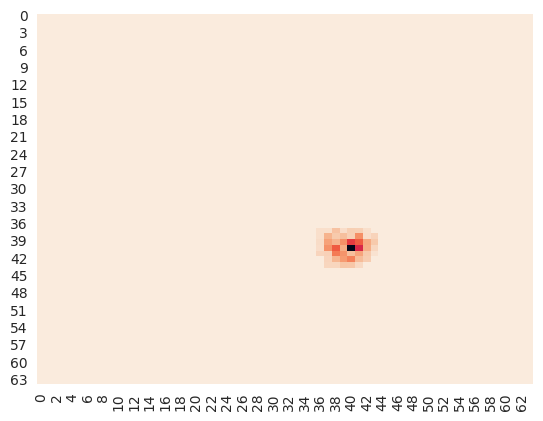

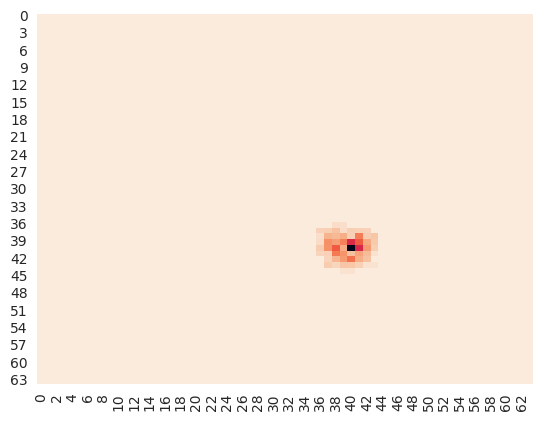

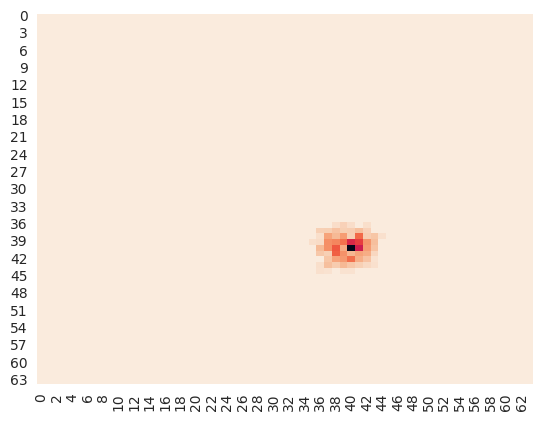

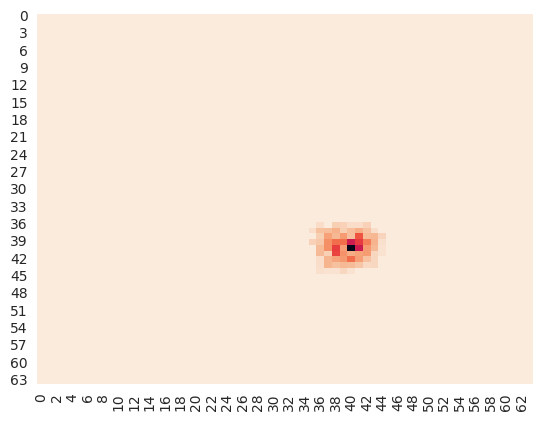

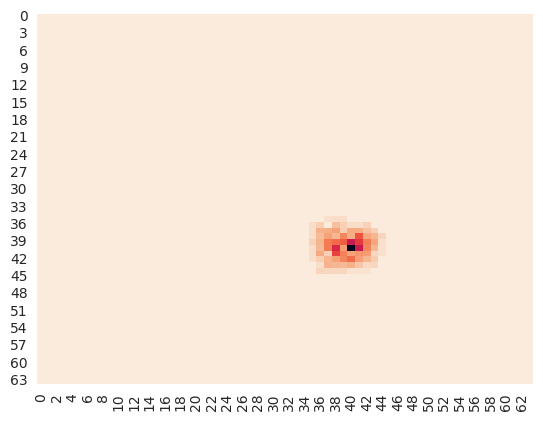

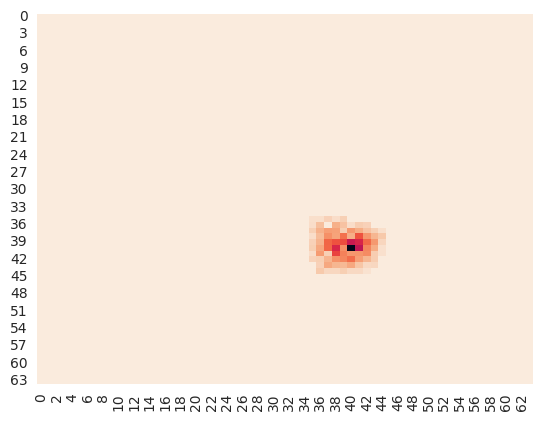

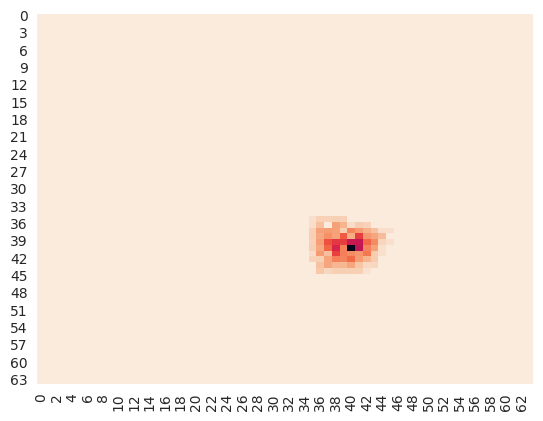

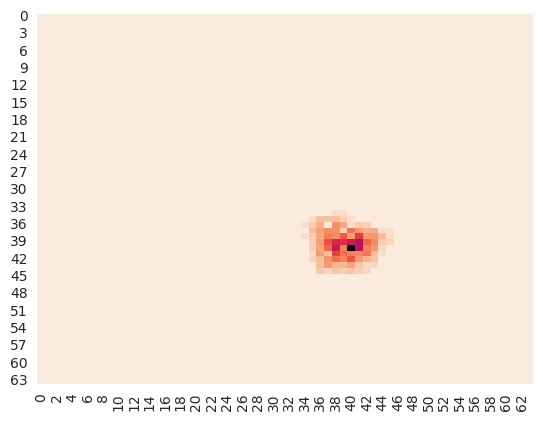

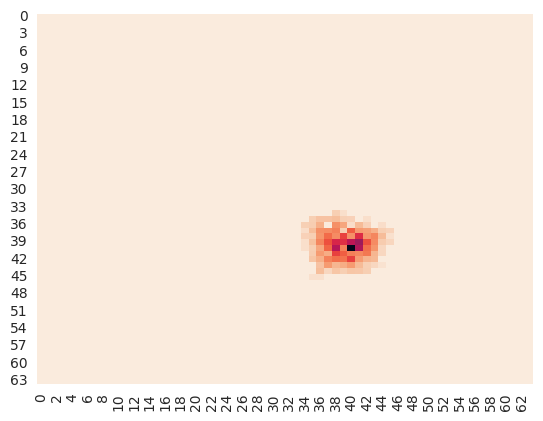

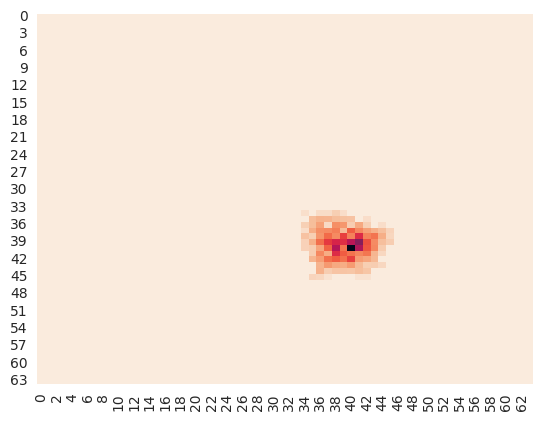

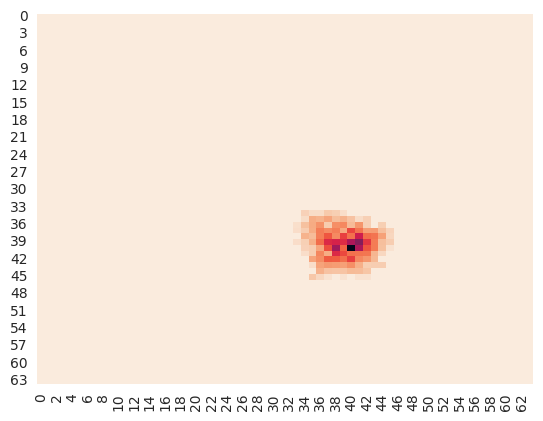

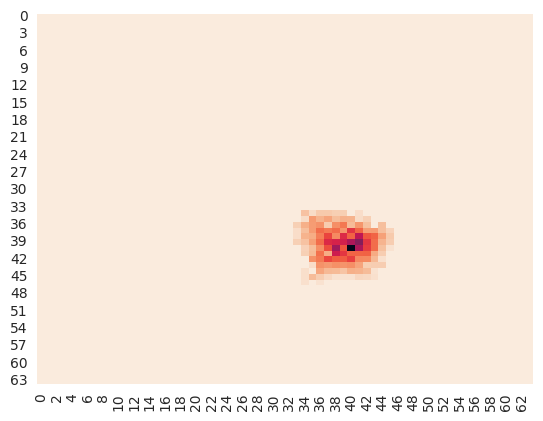

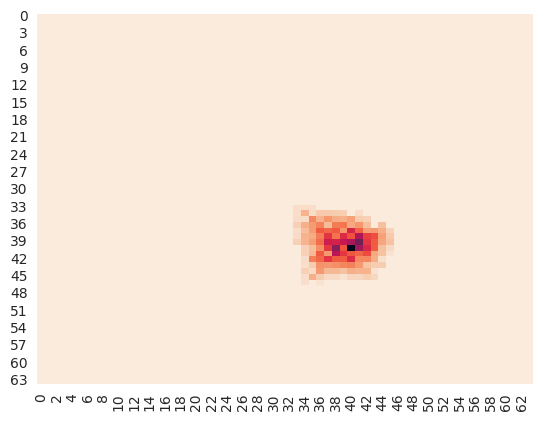

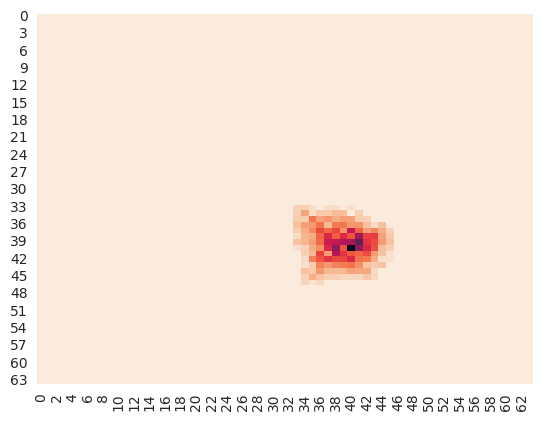

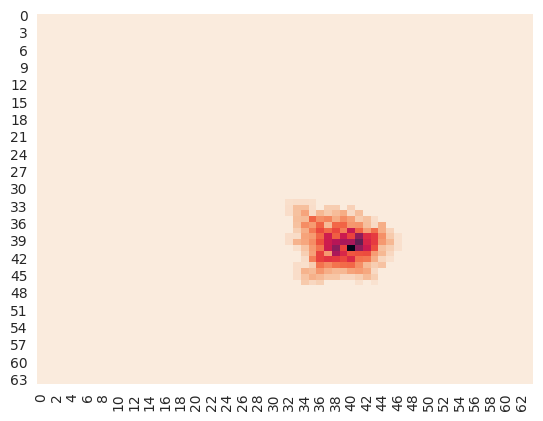

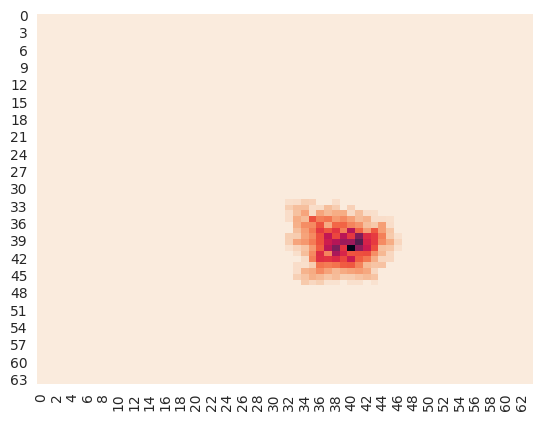

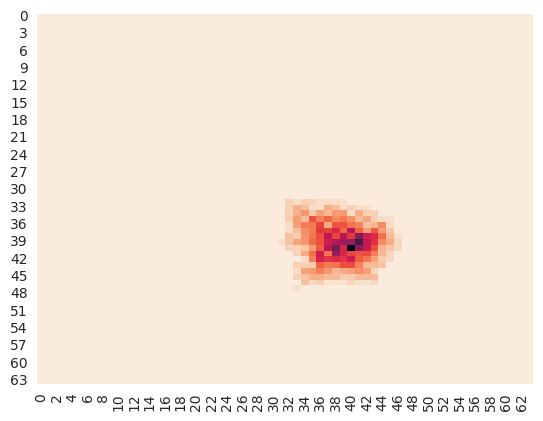

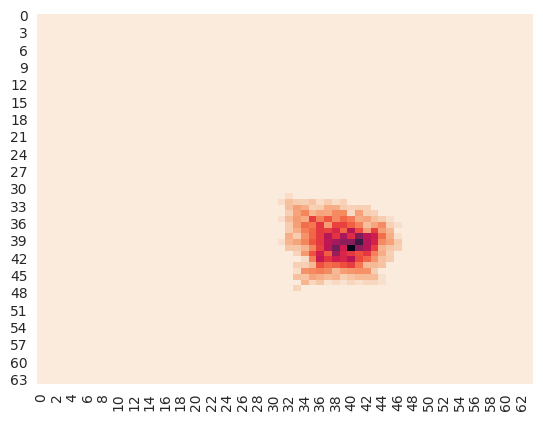

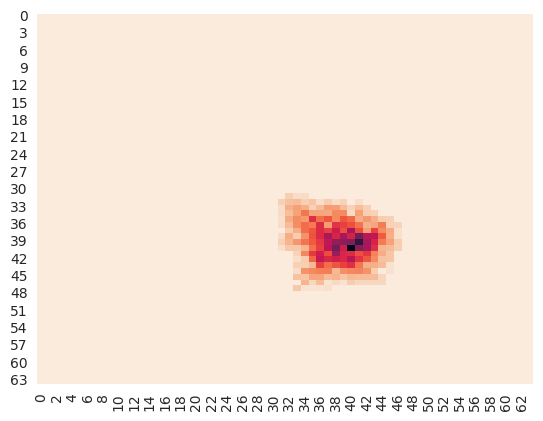

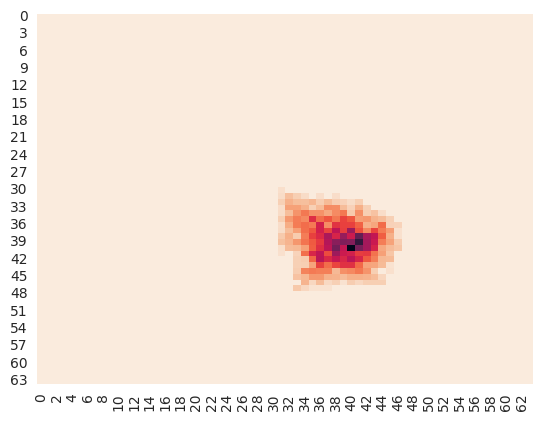

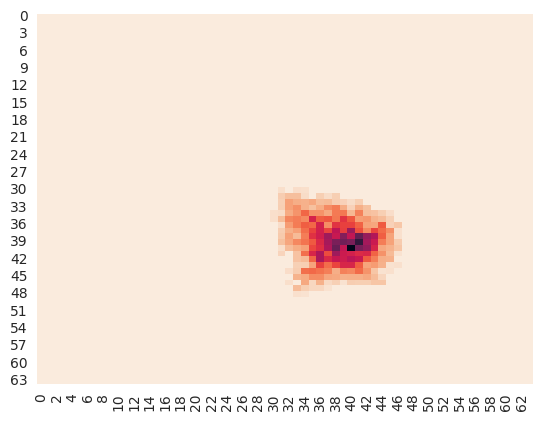

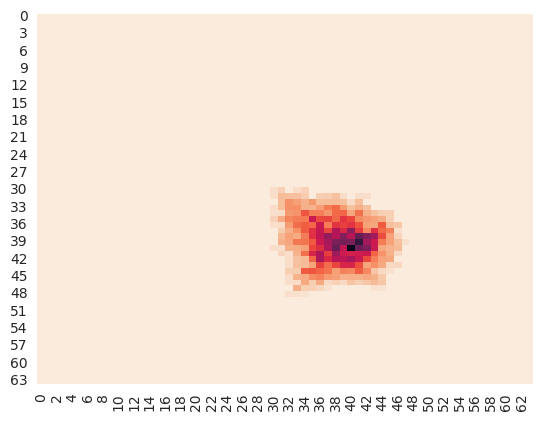

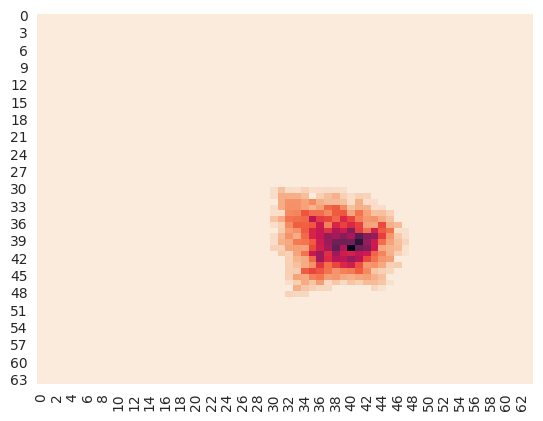

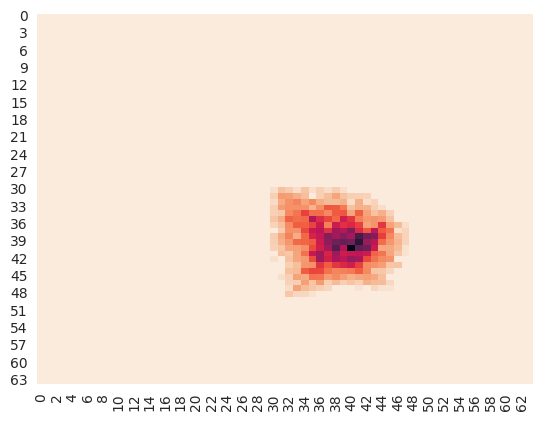

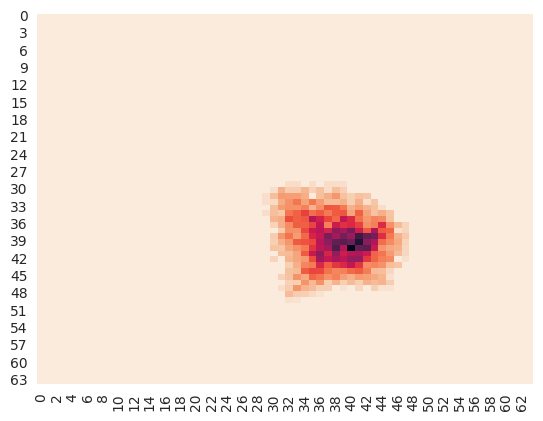

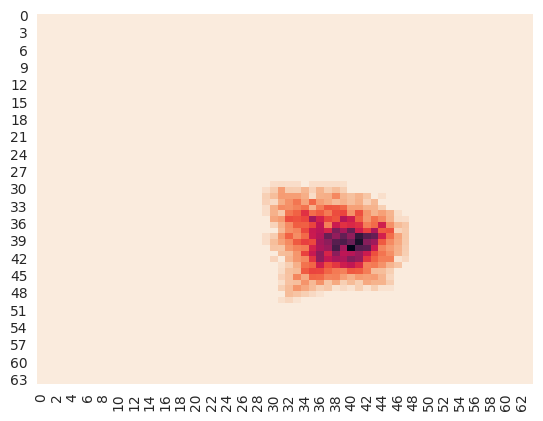

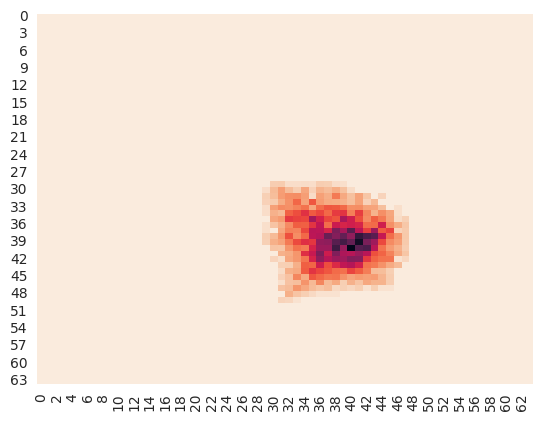

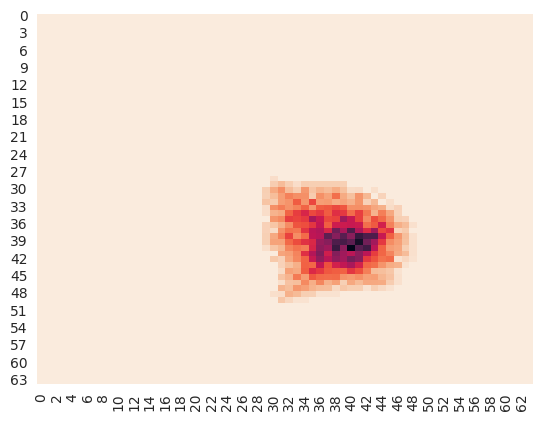

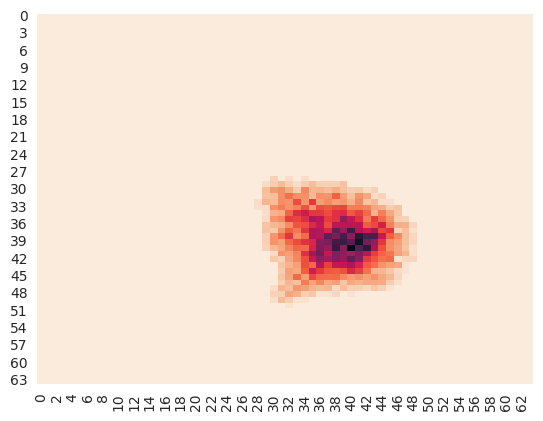

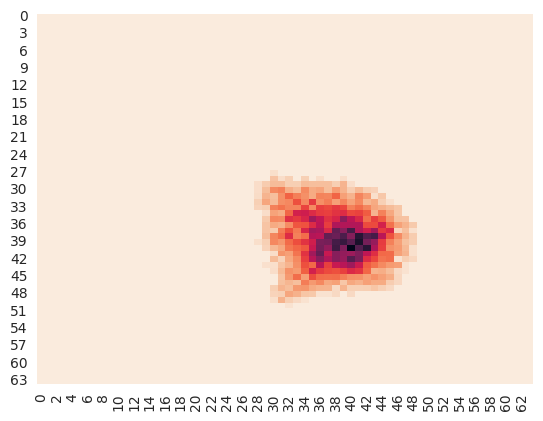

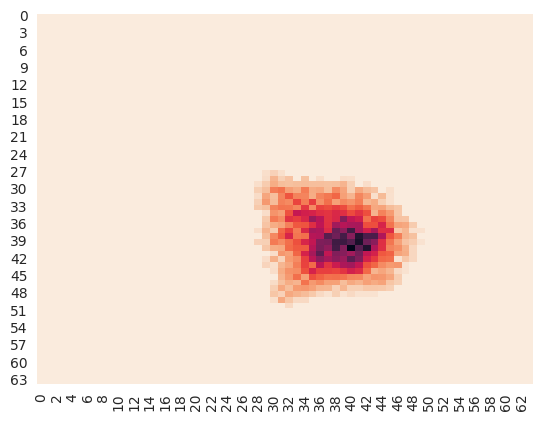

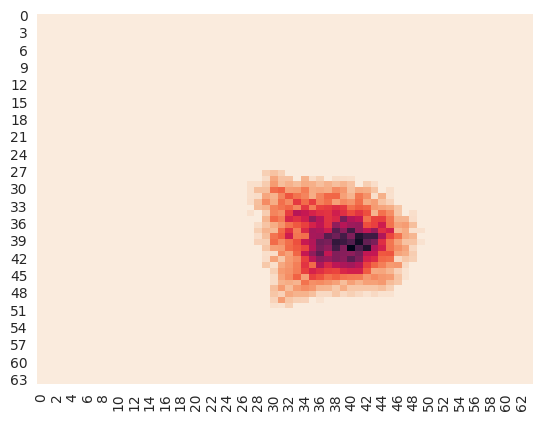

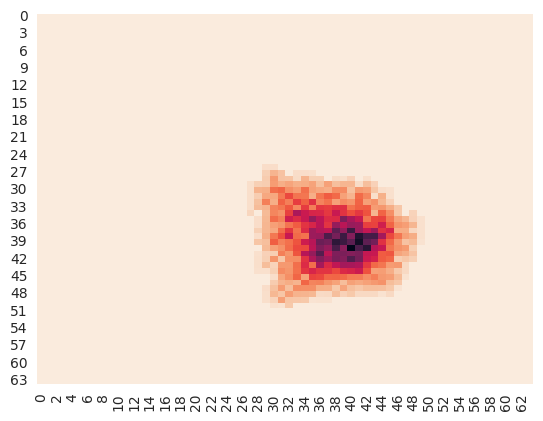

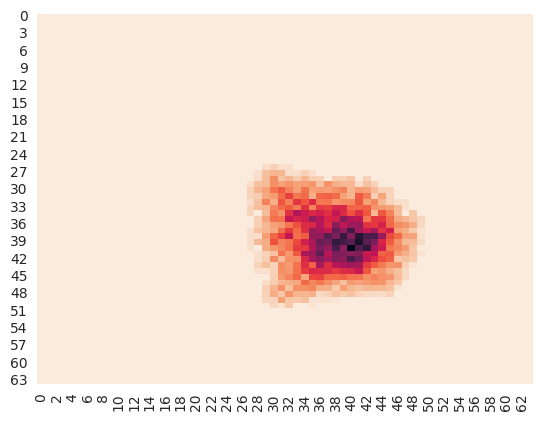

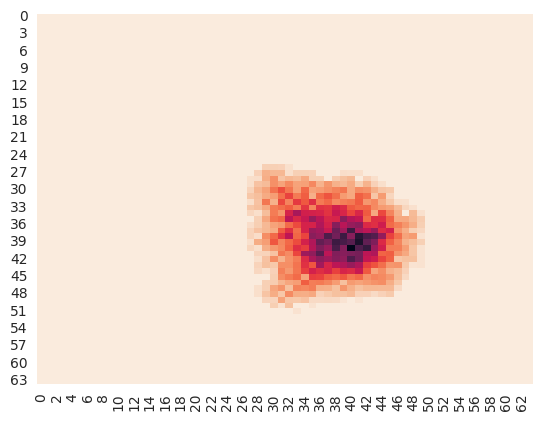

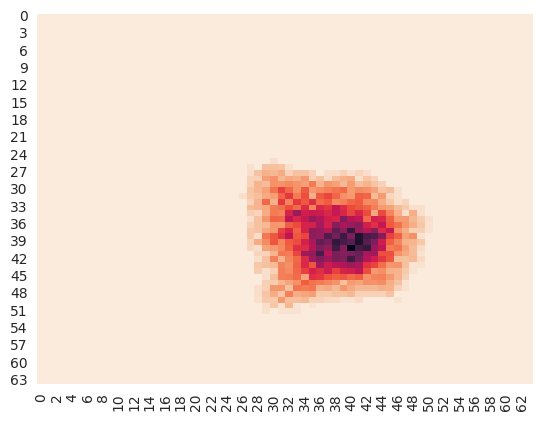

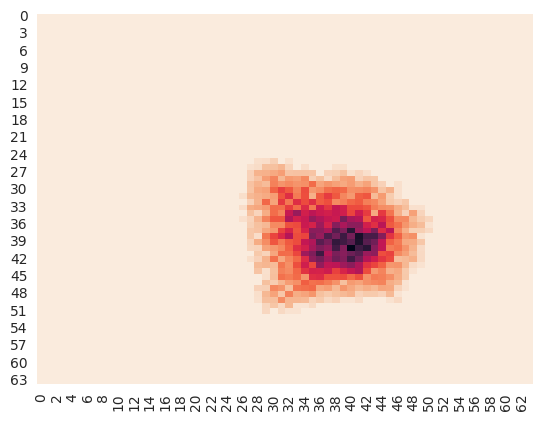

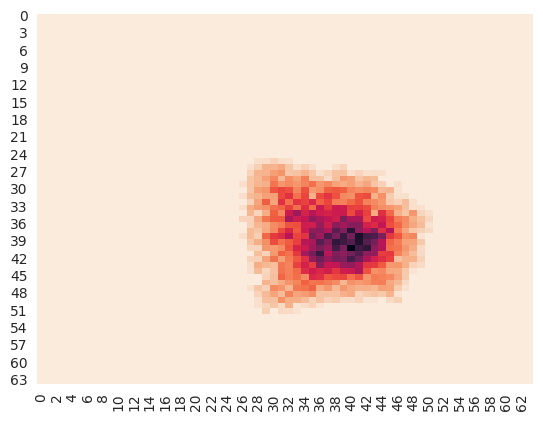

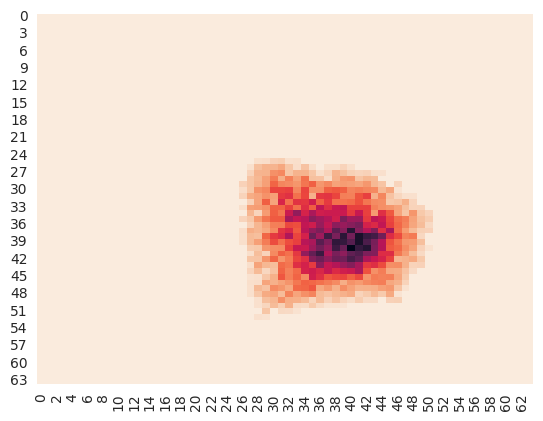

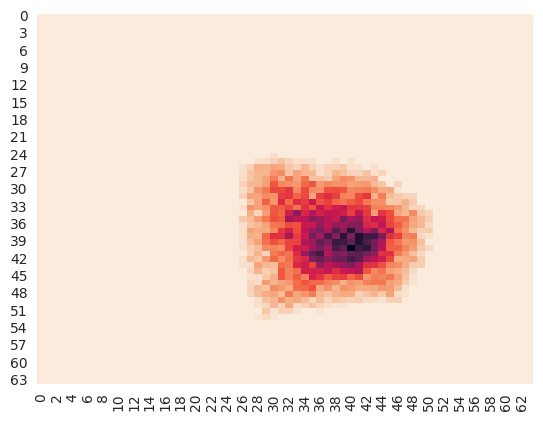

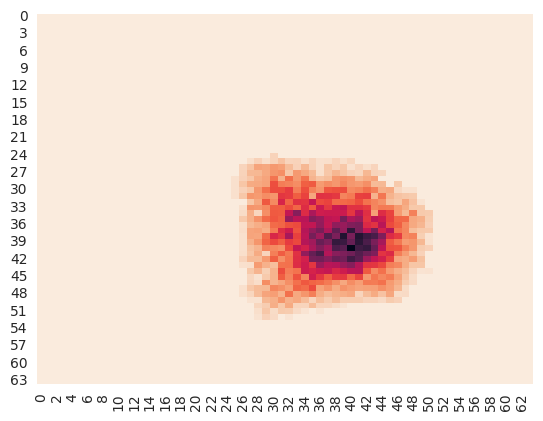

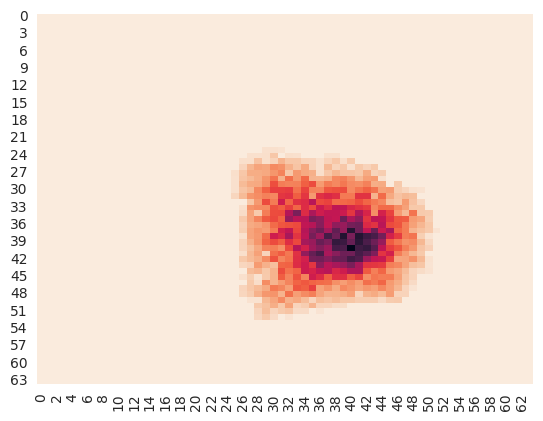

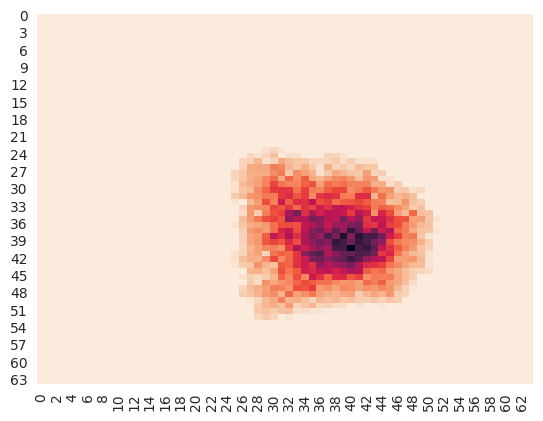

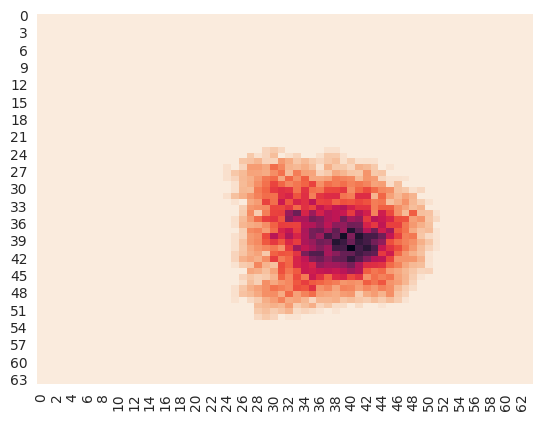

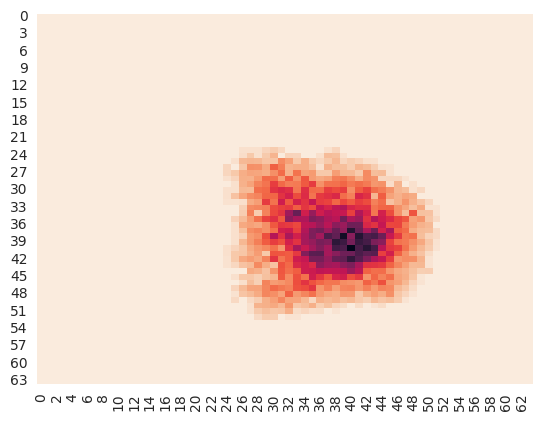

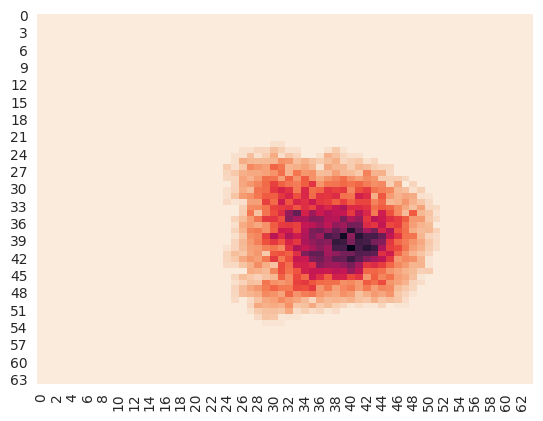

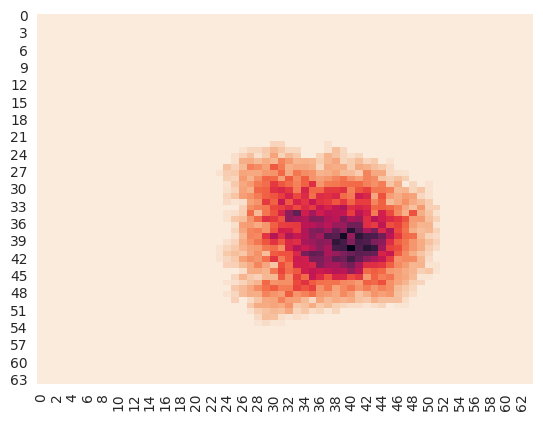

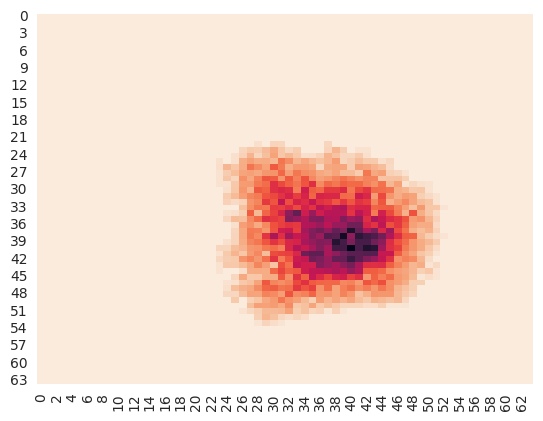

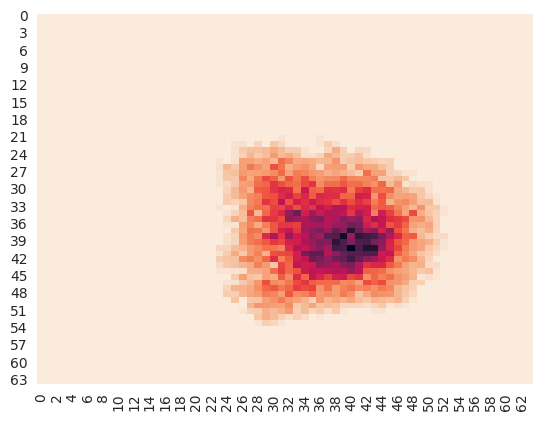

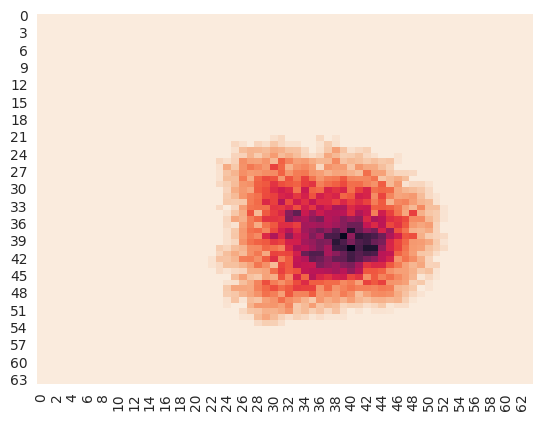

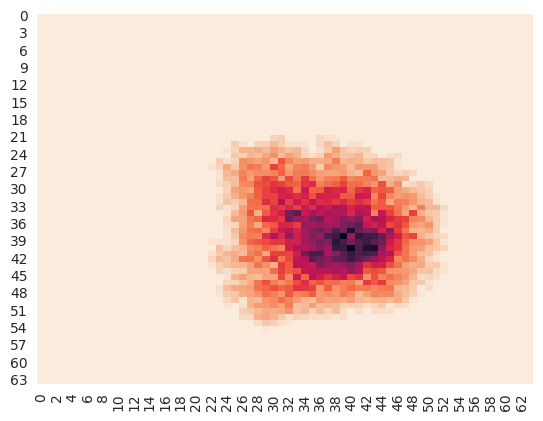

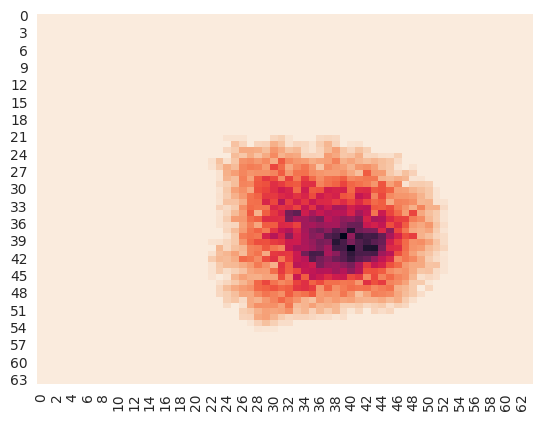

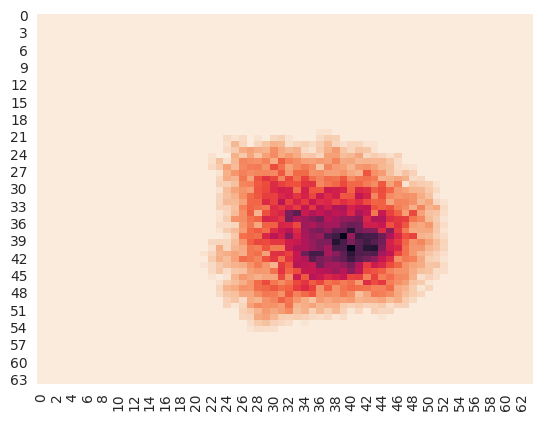

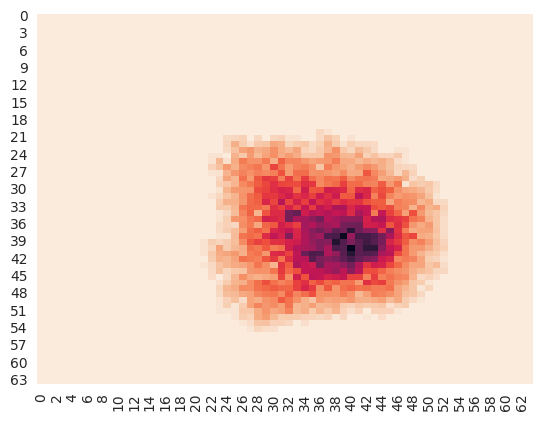

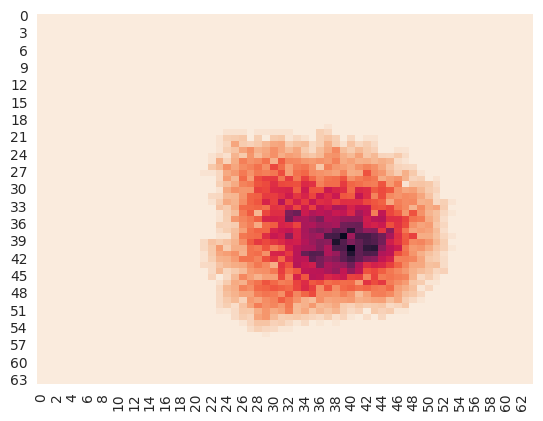

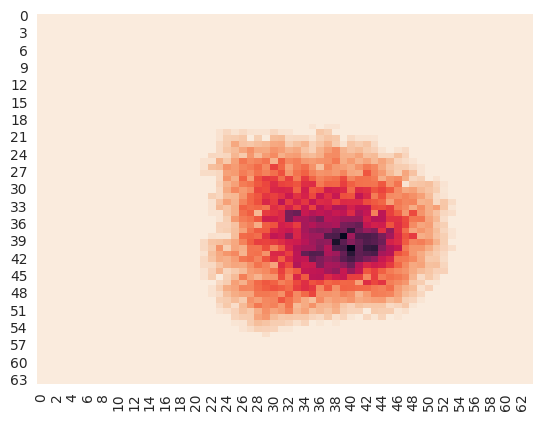

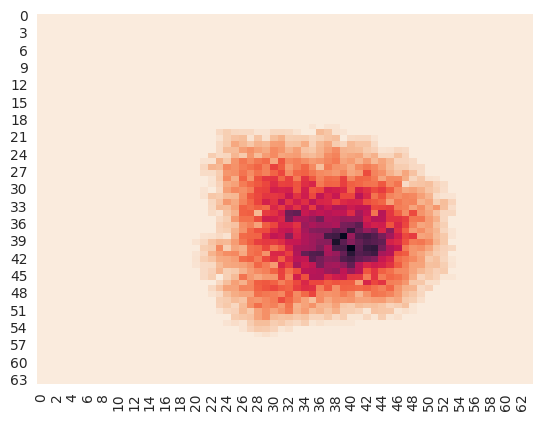

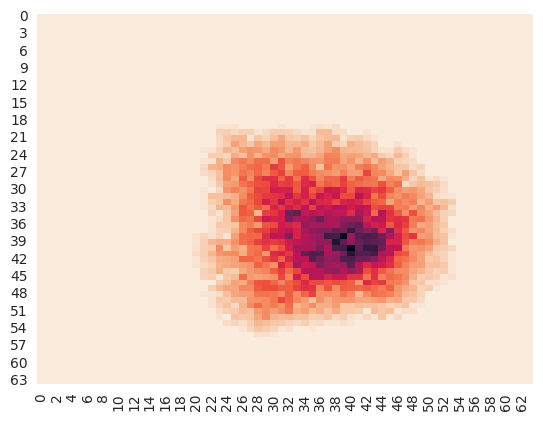

In [208]:
from IPython.display import clear_output
import time
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

state_grid = torch.zeros((64,64,16))
state_grid[40,40,:] = torch.ones(16)

update_steps = torch.randint(64, 96, (1,))
state_grids = []
for step in range(update_steps):
  perception_vectors = perception(state_grid)
  update = model(perception_vectors)
  update = stochastic_update(update)
  state_grid = state_grid + update
  state_grid = alive_mask(state_grid)

  state_grids.append(state_grid)

for state_grid in state_grids:
  sns.set_style("white")
  sns.heatmap(1-state_grid[:,:,1].cpu().detach().numpy(), cmap="rocket", cbar=False)
  plt.show()
  time.sleep(0.001)